In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


In [2]:
# 1. 加载数据集
iris = load_iris()
X = iris.data  # 特征 (150, 4)
y = iris.target  # 标签 (150,)


In [7]:
print(X[:5])
print(torch.tensor(y).bincount())

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
tensor([50, 50, 50])


In [8]:
# 2. 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # 标准化特征

print(X_scaled[:2])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]]


In [9]:
# 将数据转换为 PyTorch 张量
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [10]:
# 创建数据加载器
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [12]:
# train_dataset[:5]

for x,y in train_loader:
    print(x)
    print(y)
    break

tensor([[-5.2506e-02, -1.0528e+00,  1.3755e-01,  8.7755e-04],
        [-1.5065e+00,  3.2841e-01, -1.3402e+00, -1.3154e+00],
        [ 4.3217e-01, -3.6218e-01,  3.0806e-01,  1.3251e-01],
        [ 1.8983e-01, -8.2257e-01,  7.6276e-01,  5.2741e-01],
        [ 1.0380e+00, -1.3198e-01,  7.0592e-01,  6.5904e-01],
        [-5.2506e-02, -5.9237e-01,  7.6276e-01,  1.5805e+00],
        [-1.1430e+00,  9.8217e-02, -1.2834e+00, -1.3154e+00],
        [-1.0218e+00, -1.3198e-01, -1.2266e+00, -1.3154e+00],
        [ 3.1100e-01, -5.9237e-01,  1.3755e-01,  1.3251e-01],
        [-5.3718e-01,  1.9398e+00, -1.1697e+00, -1.0522e+00],
        [ 1.8983e-01,  7.8881e-01,  4.2173e-01,  5.2741e-01],
        [-4.1601e-01, -1.5132e+00,  2.3872e-02, -1.3075e-01],
        [-1.0218e+00,  5.5861e-01, -1.3402e+00, -1.3154e+00],
        [ 1.0380e+00,  9.8217e-02,  5.3541e-01,  3.9577e-01],
        [ 1.7650e+00, -3.6218e-01,  1.4448e+00,  7.9067e-01],
        [ 5.5333e-01, -1.7434e+00,  3.6490e-01,  1.3251e-01]])
tensor(

In [13]:
# 3. 定义神经网络模型
model = nn.Sequential(
    nn.Linear(4, 16),  # 输入层到隐藏层，4个特征输入，16个神经元
    nn.Sigmoid(),         # 激活函数
    nn.Linear(16, 3)    # 输出层，3个类别
)

# 4. 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam优化器


In [14]:
# 5. 训练模型
num_epochs = 50
for epoch in range(num_epochs):
    model.train()  # 设置模型为训练模式
    running_loss = 0.0
    for X, y in train_loader:
        optimizer.zero_grad()  # 清空梯度
        y_hat = model(X)  # 前向传播
        loss = criterion(y_hat, y)  # 计算损失
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")



Epoch [1/50], Loss: 1.1103
Epoch [2/50], Loss: 0.9693
Epoch [3/50], Loss: 0.8473
Epoch [4/50], Loss: 0.7405
Epoch [5/50], Loss: 0.6375
Epoch [6/50], Loss: 0.5682
Epoch [7/50], Loss: 0.5101
Epoch [8/50], Loss: 0.4745
Epoch [9/50], Loss: 0.4270
Epoch [10/50], Loss: 0.4104
Epoch [11/50], Loss: 0.3880
Epoch [12/50], Loss: 0.3689
Epoch [13/50], Loss: 0.3394
Epoch [14/50], Loss: 0.3341
Epoch [15/50], Loss: 0.3118
Epoch [16/50], Loss: 0.2970
Epoch [17/50], Loss: 0.2931
Epoch [18/50], Loss: 0.2631
Epoch [19/50], Loss: 0.2614
Epoch [20/50], Loss: 0.2415
Epoch [21/50], Loss: 0.2292
Epoch [22/50], Loss: 0.2257
Epoch [23/50], Loss: 0.2045
Epoch [24/50], Loss: 0.1869
Epoch [25/50], Loss: 0.1825
Epoch [26/50], Loss: 0.1690
Epoch [27/50], Loss: 0.1624
Epoch [28/50], Loss: 0.1595
Epoch [29/50], Loss: 0.1446
Epoch [30/50], Loss: 0.1484
Epoch [31/50], Loss: 0.1377
Epoch [32/50], Loss: 0.1366
Epoch [33/50], Loss: 0.1251
Epoch [34/50], Loss: 0.1306
Epoch [35/50], Loss: 0.1192
Epoch [36/50], Loss: 0.1120
E

In [15]:

# 6. 测试模型
model.eval()  # 设置模型为评估模式
correct = 0
total = 0
with torch.no_grad():  # 不计算梯度
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # 获取预测类别
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.67%


In [18]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

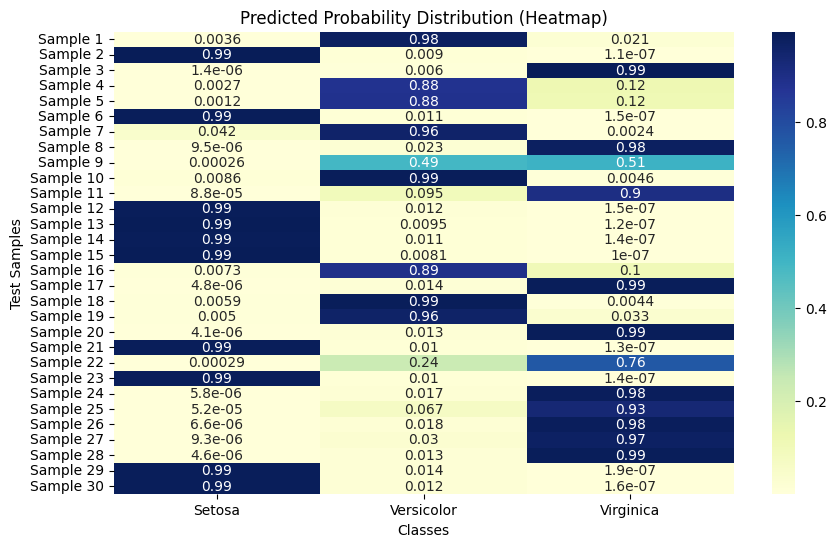

True Labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [19]:
# 测试模型
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # 将 logits 转换为概率
        all_probs.append(probs.numpy())
        all_labels.append(labels.numpy())

# 拼接所有批次的结果
all_probs = np.vstack(all_probs)
all_labels = np.hstack(all_labels)

# 创建热力图
plt.figure(figsize=(10, 6))
sns.heatmap(all_probs, annot=True, cmap="YlGnBu", cbar=True,
            xticklabels=["Setosa", "Versicolor", "Virginica"],
            yticklabels=[f"Sample {i+1}" for i in range(len(all_labels))])
plt.title("Predicted Probability Distribution (Heatmap)")
plt.xlabel("Classes")
plt.ylabel("Test Samples")
plt.show()

# 打印真实标签
print("True Labels:", all_labels)

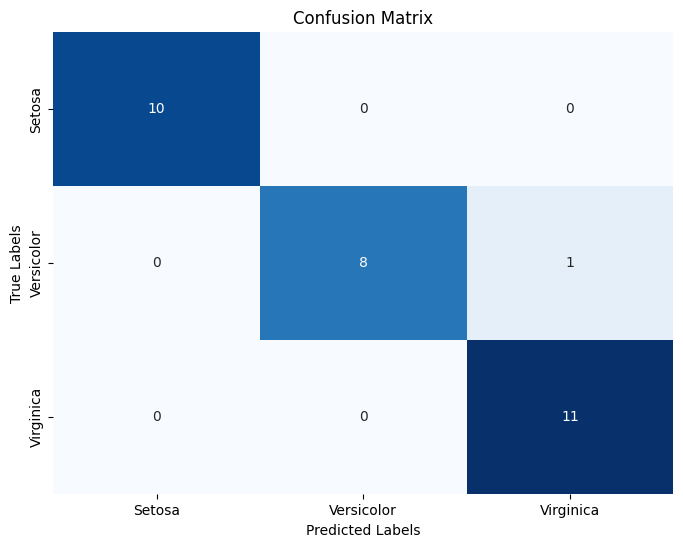

In [21]:
from sklearn.metrics import confusion_matrix
# 测试模型
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)  # 获取预测的类别
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Setosa", "Versicolor", "Virginica"],
            yticklabels=["Setosa", "Versicolor", "Virginica"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()